In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [3]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Mg_blues (µg/g DW),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,...,coarse_fragments,K,N,P,ph,sand,silt,srad_mean,ai,Mg(Soil) mg/kg
0,88,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,...,15.149744,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.83301,0.6404,38.0
1,108,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.58301,1.2798,31.0
2,139,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.58301,1.2798,31.0
3,159,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,...,25.592224,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.91699,0.9524,29.0
4,265,3798.743649,44.6500,-1.166670,12.962500,9.558333,42.293510,483.411774,25.200001,2.6,...,7.823430,237.268997,2.043349,10.124886,5.435710,70.752350,17.501411,12972.33301,0.9147,NaN


In [5]:
df=df.dropna()
df

,Accession_ID,Mg_blues (µg/g DW),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,...,coarse_fragments,K,N,P,ph,sand,silt,srad_mean,ai,Mg(Soil) mg/kg
0,88,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,...,15.149744,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.83301,0.6404,38.0
1,108,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.58301,1.2798,31.0
2,139,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.58301,1.2798,31.0
3,159,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,...,25.592224,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.91699,0.9524,29.0
5,350,5330.870503,46.6667,4.116670,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,...,12.934365,237.669601,1.743629,36.619621,6.276878,31.822845,43.187374,12031.58301,0.7753,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,9925,5226.664196,48.9100,4.520000,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,...,15.485302,288.782288,1.758133,48.285244,7.874985,22.354774,48.579197,11090.41699,0.7287,32.0
805,9933,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,...,21.798716,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.00000,0.4689,44.0
806,9938,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,...,6.823482,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.66699,0.8376,36.0
807,10020,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,...,9.075080,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.91699,0.5385,53.0


In [6]:
europe=df.loc[(df['Latitude']>36.52) & 
             (df['Latitude']<68.80) & 
             (df['Longitude']>-8.54) & 
             (df['Longitude']<38.28)]
europe

,Accession_ID,Mg_blues (µg/g DW),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,...,coarse_fragments,K,N,P,ph,sand,silt,srad_mean,ai,Mg(Soil) mg/kg
0,88,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,...,15.149744,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.83301,0.6404,38.0
1,108,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.58301,1.2798,31.0
2,139,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,11.280096,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.58301,1.2798,31.0
3,159,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,...,25.592224,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.91699,0.9524,29.0
5,350,5330.870503,46.6667,4.116670,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,...,12.934365,237.669601,1.743629,36.619621,6.276878,31.822845,43.187374,12031.58301,0.7753,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,9925,5226.664196,48.9100,4.520000,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,...,15.485302,288.782288,1.758133,48.285244,7.874985,22.354774,48.579197,11090.41699,0.7287,32.0
805,9933,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,...,21.798716,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.00000,0.4689,44.0
806,9938,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,...,6.823482,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.66699,0.8376,36.0
807,10020,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,...,9.075080,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.91699,0.5385,53.0


In [7]:
eigen_vector=pd.read_table('4PCA.eigenvec', sep=' ', header=None)
eigen_vector

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,88,88,-0.024370,-0.027794,-0.009719,-0.045172,0.020116,-0.018464,0.010127,-0.040276,...,0.022344,-0.036309,-0.021832,-0.016106,-0.014227,0.054642,0.000125,0.005087,-0.001929,-0.004083
1,108,108,-0.018917,-0.020090,-0.017147,-0.045675,0.026262,-0.033422,0.027149,-0.026217,...,0.030995,-0.032570,-0.015446,-0.008004,-0.015514,0.060124,0.006016,-0.027267,0.020782,0.022245
2,139,139,-0.020166,-0.020240,-0.015659,-0.045868,0.026783,-0.032523,0.029019,-0.030253,...,0.031710,-0.033670,-0.017462,-0.005118,-0.015275,0.061769,0.003076,-0.025756,0.019414,0.021159
3,159,159,-0.030427,-0.025171,0.001036,-0.034610,0.014473,-0.009755,0.001819,-0.033097,...,0.016474,-0.018877,-0.010793,0.000587,0.000456,0.023718,-0.006288,0.031061,-0.020006,0.015416
4,350,350,-0.029327,-0.029917,-0.002397,-0.034927,0.010089,-0.007850,-0.010276,-0.031344,...,0.032790,-0.028707,-0.026886,0.003110,-0.007435,0.037575,0.009123,0.007483,-0.006111,0.026751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,9925,9925,-0.007525,-0.008653,-0.019088,-0.039387,0.019839,-0.028435,0.015249,0.012127,...,0.022117,-0.017684,-0.002786,-0.024507,0.003899,0.015833,0.036873,-0.041042,0.030578,0.008854
574,9933,9933,-0.018095,0.010674,0.025201,0.005831,-0.002263,0.015697,0.000833,0.000679,...,-0.001507,0.022494,0.038451,-0.019393,-0.002893,-0.001982,0.027633,0.014936,-0.033421,-0.027668
575,9938,9938,-0.009516,-0.020652,-0.039450,-0.054467,0.036951,-0.066676,0.039886,0.021515,...,-0.010629,0.003953,0.011006,-0.026771,-0.007492,0.015859,-0.003797,-0.011178,0.002905,0.010727
576,10020,10020,-0.050269,0.008123,0.041430,0.020929,-0.004773,0.056435,0.050405,-0.043822,...,-0.018878,0.022926,0.009686,-0.032688,0.004943,-0.020845,0.004560,-0.031422,0.041955,0.014534


In [8]:
eigen_vector=eigen_vector.drop(columns=[1])
eigen_vector

,0,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,18,19,20,21
0,88,-0.024370,-0.027794,-0.009719,-0.045172,0.020116,-0.018464,0.010127,-0.040276,0.018976,...,0.022344,-0.036309,-0.021832,-0.016106,-0.014227,0.054642,0.000125,0.005087,-0.001929,-0.004083
1,108,-0.018917,-0.020090,-0.017147,-0.045675,0.026262,-0.033422,0.027149,-0.026217,0.010177,...,0.030995,-0.032570,-0.015446,-0.008004,-0.015514,0.060124,0.006016,-0.027267,0.020782,0.022245
2,139,-0.020166,-0.020240,-0.015659,-0.045868,0.026783,-0.032523,0.029019,-0.030253,0.013436,...,0.031710,-0.033670,-0.017462,-0.005118,-0.015275,0.061769,0.003076,-0.025756,0.019414,0.021159
3,159,-0.030427,-0.025171,0.001036,-0.034610,0.014473,-0.009755,0.001819,-0.033097,0.006524,...,0.016474,-0.018877,-0.010793,0.000587,0.000456,0.023718,-0.006288,0.031061,-0.020006,0.015416
4,350,-0.029327,-0.029917,-0.002397,-0.034927,0.010089,-0.007850,-0.010276,-0.031344,0.006669,...,0.032790,-0.028707,-0.026886,0.003110,-0.007435,0.037575,0.009123,0.007483,-0.006111,0.026751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,9925,-0.007525,-0.008653,-0.019088,-0.039387,0.019839,-0.028435,0.015249,0.012127,0.007894,...,0.022117,-0.017684,-0.002786,-0.024507,0.003899,0.015833,0.036873,-0.041042,0.030578,0.008854
574,9933,-0.018095,0.010674,0.025201,0.005831,-0.002263,0.015697,0.000833,0.000679,-0.005746,...,-0.001507,0.022494,0.038451,-0.019393,-0.002893,-0.001982,0.027633,0.014936,-0.033421,-0.027668
575,9938,-0.009516,-0.020652,-0.039450,-0.054467,0.036951,-0.066676,0.039886,0.021515,-0.030235,...,-0.010629,0.003953,0.011006,-0.026771,-0.007492,0.015859,-0.003797,-0.011178,0.002905,0.010727
576,10020,-0.050269,0.008123,0.041430,0.020929,-0.004773,0.056435,0.050405,-0.043822,0.025910,...,-0.018878,0.022926,0.009686,-0.032688,0.004943,-0.020845,0.004560,-0.031422,0.041955,0.014534


In [9]:
eigen_vector.columns = ['Accession_ID', 
                        'PC1',
                        'PC2',
                        'PC3',
                        'PC4',
                        'PC5',
                        'PC6',
                        'PC7',
                        'PC8',
                        'PC9',
                        'PC10',
                        'PC11',
                        'PC12',
                        'PC13',
                        'PC14',
                        'PC15',
                        'PC16',
                        'PC17',
                        'PC18',
                        'PC19',
                        'PC20']
eigen_vector

,Accession_ID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,88,-0.024370,-0.027794,-0.009719,-0.045172,0.020116,-0.018464,0.010127,-0.040276,0.018976,...,0.022344,-0.036309,-0.021832,-0.016106,-0.014227,0.054642,0.000125,0.005087,-0.001929,-0.004083
1,108,-0.018917,-0.020090,-0.017147,-0.045675,0.026262,-0.033422,0.027149,-0.026217,0.010177,...,0.030995,-0.032570,-0.015446,-0.008004,-0.015514,0.060124,0.006016,-0.027267,0.020782,0.022245
2,139,-0.020166,-0.020240,-0.015659,-0.045868,0.026783,-0.032523,0.029019,-0.030253,0.013436,...,0.031710,-0.033670,-0.017462,-0.005118,-0.015275,0.061769,0.003076,-0.025756,0.019414,0.021159
3,159,-0.030427,-0.025171,0.001036,-0.034610,0.014473,-0.009755,0.001819,-0.033097,0.006524,...,0.016474,-0.018877,-0.010793,0.000587,0.000456,0.023718,-0.006288,0.031061,-0.020006,0.015416
4,350,-0.029327,-0.029917,-0.002397,-0.034927,0.010089,-0.007850,-0.010276,-0.031344,0.006669,...,0.032790,-0.028707,-0.026886,0.003110,-0.007435,0.037575,0.009123,0.007483,-0.006111,0.026751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,9925,-0.007525,-0.008653,-0.019088,-0.039387,0.019839,-0.028435,0.015249,0.012127,0.007894,...,0.022117,-0.017684,-0.002786,-0.024507,0.003899,0.015833,0.036873,-0.041042,0.030578,0.008854
574,9933,-0.018095,0.010674,0.025201,0.005831,-0.002263,0.015697,0.000833,0.000679,-0.005746,...,-0.001507,0.022494,0.038451,-0.019393,-0.002893,-0.001982,0.027633,0.014936,-0.033421,-0.027668
575,9938,-0.009516,-0.020652,-0.039450,-0.054467,0.036951,-0.066676,0.039886,0.021515,-0.030235,...,-0.010629,0.003953,0.011006,-0.026771,-0.007492,0.015859,-0.003797,-0.011178,0.002905,0.010727
576,10020,-0.050269,0.008123,0.041430,0.020929,-0.004773,0.056435,0.050405,-0.043822,0.025910,...,-0.018878,0.022926,0.009686,-0.032688,0.004943,-0.020845,0.004560,-0.031422,0.041955,0.014534


In [10]:
df4model=europe.merge(eigen_vector, how='left', on='Accession_ID')
df4model

,Accession_ID,Mg_blues (µg/g DW),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,88,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,...,0.022344,-0.036309,-0.021832,-0.016106,-0.014227,0.054642,0.000125,0.005087,-0.001929,-0.004083
1,108,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,0.030995,-0.032570,-0.015446,-0.008004,-0.015514,0.060124,0.006016,-0.027267,0.020782,0.022245
2,139,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,0.031710,-0.033670,-0.017462,-0.005118,-0.015275,0.061769,0.003076,-0.025756,0.019414,0.021159
3,159,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,...,0.016474,-0.018877,-0.010793,0.000587,0.000456,0.023718,-0.006288,0.031061,-0.020006,0.015416
4,350,5330.870503,46.6667,4.116670,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,...,0.032790,-0.028707,-0.026886,0.003110,-0.007435,0.037575,0.009123,0.007483,-0.006111,0.026751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,9925,5226.664196,48.9100,4.520000,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,...,0.022117,-0.017684,-0.002786,-0.024507,0.003899,0.015833,0.036873,-0.041042,0.030578,0.008854
574,9933,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,...,-0.001507,0.022494,0.038451,-0.019393,-0.002893,-0.001982,0.027633,0.014936,-0.033421,-0.027668
575,9938,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,...,-0.010629,0.003953,0.011006,-0.026771,-0.007492,0.015859,-0.003797,-0.011178,0.002905,0.010727
576,10020,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,...,-0.018878,0.022926,0.009686,-0.032688,0.004943,-0.020845,0.004560,-0.031422,0.041955,0.014534


In [14]:
df4model.columns.to_list()

['Accession_ID',
 'Mg_blues (µg/g DW)',
 'Latitude',
 'Longitude',
 'bio1',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'AWC',
 'bulk density',
 'CaCO$_3$',
 'CEC',
 'clay',
 'CN',
 'coarse frag',
 'K',
 'N',
 'P',
 'ph',
 'sand',
 'silt',
 'srad',
 'AI',
 'Mg(Soil) mg/kg',
 'PC1',
 'PC2',
 'PC3',
 'PC4',
 'PC5',
 'PC6',
 'PC7',
 'PC8',
 'PC9',
 'PC10',
 'PC11',
 'PC12',
 'PC13',
 'PC14',
 'PC15',
 'PC16',
 'PC17',
 'PC18',
 'PC19',
 'PC20']

In [15]:
df4model=df4model.rename(columns={'coarse_fragments':'coarse frag',
                      'bulk_density':'bulk density',
                      'CaCO3':'CaCO$_3$',
                      'ai':'AI',
                      'awc':'AWC',
                      'Mg(Soil) mg/kg':'Mg(Soil)',
                      'Mg_blues (µg/g DW)':'Mg(Leaf)',
                      'srad_mean':'srad',
                     })
df4model

,Accession_ID,Mg(Leaf),Latitude,Longitude,bio1,bio2,bio3,bio4,bio5,bio6,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,88,4381.237684,47.4000,0.683333,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,...,0.022344,-0.036309,-0.021832,-0.016106,-0.014227,0.054642,0.000125,0.005087,-0.001929,-0.004083
1,108,4249.456382,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,0.030995,-0.032570,-0.015446,-0.008004,-0.015514,0.060124,0.006016,-0.027267,0.020782,0.022245
2,139,4489.038748,48.5167,-4.066670,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,...,0.031710,-0.033670,-0.017462,-0.005118,-0.015275,0.061769,0.003076,-0.025756,0.019414,0.021159
3,159,4812.735886,47.3500,3.933330,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,...,0.016474,-0.018877,-0.010793,0.000587,0.000456,0.023718,-0.006288,0.031061,-0.020006,0.015416
4,350,5330.870503,46.6667,4.116670,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,...,0.032790,-0.028707,-0.026886,0.003110,-0.007435,0.037575,0.009123,0.007483,-0.006111,0.026751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,9925,5226.664196,48.9100,4.520000,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,...,0.022117,-0.017684,-0.002786,-0.024507,0.003899,0.015833,0.036873,-0.041042,0.030578,0.008854
574,9933,5149.871903,43.7400,3.890000,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,...,-0.001507,0.022494,0.038451,-0.019393,-0.002893,-0.001982,0.027633,0.014936,-0.033421,-0.027668
575,9938,4967.209695,50.6500,2.990000,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,...,-0.010629,0.003953,0.011006,-0.026771,-0.007492,0.015859,-0.003797,-0.011178,0.002905,0.010727
576,10020,5158.205468,49.1700,16.500000,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,...,-0.018878,0.022926,0.009686,-0.032688,0.004943,-0.020845,0.004560,-0.031422,0.041955,0.014534


In [25]:
df4model=df4model.drop(columns=['Latitude','Longitude'])
df4model

,Accession_ID,Mg(Leaf),bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,88,4381.237684,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,23.299999,6.050000,...,0.022344,-0.036309,-0.021832,-0.016106,-0.014227,0.054642,0.000125,0.005087,-0.001929,-0.004083
1,108,4249.456382,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,7.566667,...,0.030995,-0.032570,-0.015446,-0.008004,-0.015514,0.060124,0.006016,-0.027267,0.020782,0.022245
2,139,4489.038748,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,7.566667,...,0.031710,-0.033670,-0.017462,-0.005118,-0.015275,0.061769,0.003076,-0.025756,0.019414,0.021159
3,159,4812.735886,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,23.800001,3.216667,...,0.016474,-0.018877,-0.010793,0.000587,0.000456,0.023718,-0.006288,0.031061,-0.020006,0.015416
4,350,5330.870503,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,25.799999,16.683332,...,0.032790,-0.028707,-0.026886,0.003110,-0.007435,0.037575,0.009123,0.007483,-0.006111,0.026751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,9925,5226.664196,10.491667,9.450000,36.914062,595.848633,25.299999,-0.3,25.599998,18.049999,...,0.022117,-0.017684,-0.002786,-0.024507,0.003899,0.015833,0.036873,-0.041042,0.030578,0.008854
574,9933,5149.871903,14.079166,9.141666,35.296009,605.116272,28.400000,2.5,25.900000,10.666667,...,-0.001507,0.022494,0.038451,-0.019393,-0.002893,-0.001982,0.027633,0.014936,-0.033421,-0.027668
575,9938,4967.209695,10.345834,7.675000,34.417042,542.320190,23.100000,0.8,22.300001,10.916667,...,-0.010629,0.003953,0.011006,-0.026771,-0.007492,0.015859,-0.003797,-0.011178,0.002905,0.010727
576,10020,5158.205468,8.854167,8.458333,29.994089,755.646790,24.200001,-4.0,28.200001,16.566668,...,-0.018878,0.022926,0.009686,-0.032688,0.004943,-0.020845,0.004560,-0.031422,0.041955,0.014534


In [26]:
X=df4model.drop(columns=['Mg(Leaf)'])
y=df4model['Mg(Leaf)']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [28]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
441,7.620833,9.941667,34.639954,708.851379,23.200001,-5.5,28.700001,11.050000,13.016667,16.216667,...,0.006314,0.022825,0.015789,-0.051381,-0.018442,0.017320,0.017839,0.021053,-0.029712,-0.037941
403,13.729167,8.091666,32.627686,615.801269,27.700001,2.9,24.800001,11.083333,21.666666,21.666666,...,0.041444,0.019792,0.006382,-0.043634,-0.014353,0.015218,0.013225,0.017243,-0.023431,-0.012720
119,3.491667,7.500000,25.951557,764.602783,19.299999,-9.6,28.900000,3.850000,1.833333,13.533334,...,-0.003190,-0.073423,0.046961,-0.007247,-0.002428,0.004492,-0.001184,0.002126,-0.039455,0.036147
517,14.395833,13.791667,39.745438,742.129761,34.799999,0.1,34.700001,9.900000,23.949999,24.183332,...,-0.001542,-0.014039,0.000942,-0.000286,0.005302,0.002997,0.045158,0.023414,0.016080,0.023138
494,8.800000,9.266666,34.837093,659.152344,23.700001,-2.9,26.600000,15.400001,1.933333,17.016666,...,-0.023564,-0.011990,-0.008947,0.007425,0.000895,0.014713,-0.009445,0.000302,0.002516,0.010431


In [29]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
192,10.016666,7.966667,31.739708,658.694763,24.100000,-1.0,25.100000,16.700001,5.866667,18.316668,...,0.030254,-0.007852,0.005713,0.002776,-0.012687,-0.008023,0.017189,-0.001997,-0.008796,-0.028995
419,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,0.013187,-0.045301,0.018971,-0.069047,0.323965,0.056664,-0.001359,-0.065316,-0.151122,0.011568
350,10.087500,14.258333,43.737217,654.384277,29.200001,-3.4,32.600002,11.800000,18.516666,18.666666,...,0.001852,-0.010871,-0.003098,-0.023902,-0.009564,0.029331,-0.018365,-0.009385,-0.015158,-0.023029
410,10.870833,9.858334,33.081654,754.644592,26.700001,-3.1,29.800001,20.183334,3.500000,20.183334,...,0.010164,0.006903,-0.018467,0.042623,-0.123345,-0.050528,0.014682,-0.038449,-0.082463,0.059920
480,8.125000,9.116667,34.144817,664.264832,23.000000,-3.7,26.700001,14.816667,1.233333,16.416666,...,-0.031968,-0.004695,0.006655,0.017493,0.011480,-0.004812,-0.031367,-0.005720,0.005974,-0.005006


In [30]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 8, 'n_estimators': 200}
0.2006416205167333


In [31]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 520.79
Mean Squared Error: 383601.01
R-squared scores: 0.3


In [32]:
from sklearn.inspection import permutation_importance

result = permutation_importance(forest_model_cv, X_test, y_test, n_repeats=1000, n_jobs=4)
model_importances = pd.Series(result.importances_mean, index=X_train.columns)

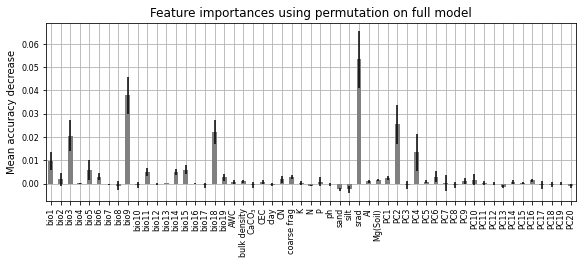

In [33]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(21*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)

fig.tight_layout()
ax.tick_params(axis='both', which='major', labelsize=8)
# plt.savefig("Fig1c.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")